In [1]:
import pandas as pd

file_path = "../data/cleaned_marketing_campaign_data.csv"

df = pd.read_csv(file_path)

df.head()

,campaign_id,company,campaign_type,target_audience,duration,channel_used,conversion_rate,acquisition_cost,roi,location,language,clicks,impressions,engagement_score,customer_segment,date,ctr,engagement_efficiency
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01,0.263267,0.011858
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02,0.015419,0.060345
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03,0.075864,0.001712
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04,0.119231,0.032258
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05,0.090217,0.007916


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df.shape

(200000, 18)

In [4]:
df.columns

Index(['campaign_id', 'company', 'campaign_type', 'target_audience',
       'duration', 'channel_used', 'conversion_rate', 'acquisition_cost',
       'roi', 'location', 'language', 'clicks', 'impressions',
       'engagement_score', 'customer_segment', 'date', 'ctr',
       'engagement_efficiency'],
      dtype='object')

In [6]:
df.describe()

,campaign_id,conversion_rate,roi,clicks,impressions,engagement_score,ctr,engagement_efficiency
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,100000.500000,0.080070,5.002438,549.772030,5507.301520,5.494710,0.140405,0.014091
std,57735.171256,0.040602,1.734488,260.019056,2596.864286,2.872581,0.130881,0.013736
min,1.000000,0.010000,2.000000,100.000000,1000.000000,1.000000,0.010054,0.001000
25%,50000.750000,0.050000,3.500000,325.000000,3266.000000,3.000000,0.058606,0.005445
50%,100000.500000,0.080000,5.010000,550.000000,5517.500000,5.000000,0.099789,0.010011
75%,150000.250000,0.120000,6.510000,775.000000,7753.000000,8.000000,0.169699,0.017143
max,200000.000000,0.150000,8.000000,1000.000000,10000.000000,10.000000,0.992024,0.100000


In [7]:
df.groupby('channel_used')[['roi','conversion_rate','ctr']].mean().sort_values(by='roi', ascending=False)

,roi,conversion_rate,ctr
channel_used,,,
Facebook,5.018699,0.079992,0.140499
Website,5.014167,0.080183,0.140971
Google Ads,5.003141,0.080183,0.139190
Email,4.996487,0.080282,0.140543
YouTube,4.993754,0.079889,0.141196
Instagram,4.988706,0.079886,0.140037


In [8]:
df.groupby('campaign_type')[['roi','conversion_rate','engagement_score']].mean().sort_values(by='roi', ascending=False)

,roi,conversion_rate,engagement_score
campaign_type,,,
Influencer,5.011068,0.080315,5.483134
Search,5.008357,0.080021,5.487138
Display,5.006551,0.080089,5.505889
Email,4.994295,0.079788,5.499624
Social Media,4.991784,0.080135,5.497878


In [9]:
df.groupby('customer_segment')[['roi','conversion_rate']].mean().sort_values(by='roi', ascending=False)

,roi,conversion_rate
customer_segment,,
Foodies,5.004376,0.080257
Tech Enthusiasts,5.004234,0.080168
Health & Wellness,5.003202,0.079945
Fashionistas,5.000962,0.079794
Outdoor Adventurers,4.999393,0.080180


In [10]:
df.groupby('location')[['roi','conversion_rate']].mean().sort_values(by='roi', ascending=False)

,roi,conversion_rate
location,,
Miami,5.012282,0.080047
Los Angeles,5.010876,0.080013
Houston,5.007203,0.079948
Chicago,5.001590,0.080134
New York,4.980228,0.080204


In [11]:
df.groupby('target_audience')[['roi','conversion_rate']].mean().sort_values(by='roi', ascending=False)

,roi,conversion_rate
target_audience,,
Men 25-34,5.020627,0.080132
Women 35-44,5.006330,0.080102
All Ages,5.005174,0.079975
Women 25-34,4.997351,0.079899
Men 18-24,4.982853,0.080240


In [12]:
df['date'] = pd.to_datetime(df['date'])

In [13]:
df.groupby(df['date'].dt.month)['roi'].mean()

date
1     5.014595
2     5.005248
3     4.983404
4     4.994372
5     5.018923
6     4.985203
7     4.983045
8     4.997793
9     5.029044
10    5.016445
11    4.999271
12    5.002122
Name: roi, dtype: float64

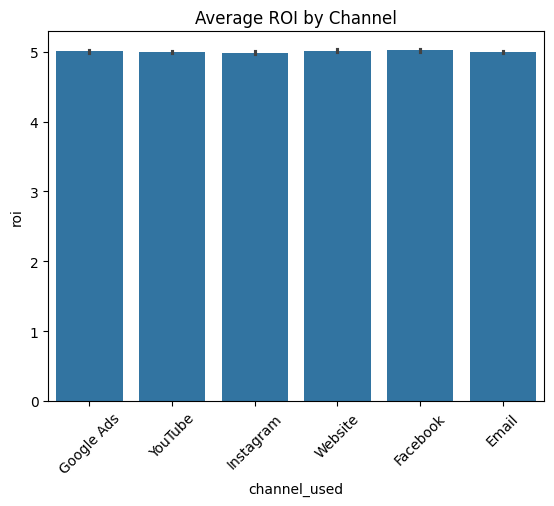

In [14]:
sns.barplot(data=df, x='channel_used', y='roi')
plt.title("Average ROI by Channel")
plt.xticks(rotation=45)
plt.show()

### Channel Performance Analysis

This section evaluates average ROI, conversion rate, and CTR across marketing channels to identify the most effective channel.

In [16]:
df['acquisition_cost'] = df['acquisition_cost'].replace('[\$,]', '', regex=True).astype(float)

In [17]:
df['roi'] = df['roi'].replace('[\$,]', '', regex=True).astype(float)

In [18]:
df[['roi','acquisition_cost']].head()

,roi,acquisition_cost
0,6.29,16174.0
1,5.61,11566.0
2,7.18,10200.0
3,5.55,12724.0
4,6.50,16452.0


In [19]:
df.groupby('campaign_type')[['roi','acquisition_cost']].mean().sort_values(by='roi', ascending=False)

,roi,acquisition_cost
campaign_type,,
Influencer,5.011068,12507.170330
Search,5.008357,12498.736459
Display,5.006551,12508.034461
Email,4.994295,12495.346100
Social Media,4.991784,12512.698094


In [20]:
df.groupby('channel_used')['ctr'].mean().sort_values(ascending=False)

channel_used
YouTube       0.141196
Website       0.140971
Email         0.140543
Facebook      0.140499
Instagram     0.140037
Google Ads    0.139190
Name: ctr, dtype: float64

In [21]:
df.groupby('channel_used')['engagement_score'].mean().sort_values(ascending=False)

channel_used
Website       5.508903
Facebook      5.503702
Google Ads    5.494049
Instagram     5.489039
Email         5.487842
YouTube       5.484937
Name: engagement_score, dtype: float64

In [22]:
df.groupby('duration')[['roi','conversion_rate']].mean()

,roi,conversion_rate
duration,,
15 days,4.996720,0.080101
30 days,5.008887,0.080177
45 days,4.997627,0.079952
60 days,5.006480,0.080048


In [23]:
df.groupby('language')[['roi','conversion_rate']].mean().sort_values(by='roi', ascending=False)

,roi,conversion_rate
language,,
French,5.011375,0.080254
Mandarin,5.007313,0.080036
Spanish,5.001705,0.079918
German,5.001054,0.079973
English,4.990734,0.080169


In [24]:
df.groupby('company')[['roi','conversion_rate']].mean().sort_values(by='roi', ascending=False)

,roi,conversion_rate
company,,
TechCorp,5.007143,0.080157
Alpha Innovations,5.005944,0.080084
DataTech Solutions,5.005537,0.079989
Innovate Industries,5.002175,0.080384
NexGen Systems,4.991353,0.079736


In [25]:
df.groupby('channel_used')['engagement_efficiency'].mean().sort_values(ascending=False)

channel_used
Google Ads    0.014255
Facebook      0.014170
Instagram     0.014100
YouTube       0.014070
Website       0.014009
Email         0.013942
Name: engagement_efficiency, dtype: float64

In [26]:
df[['roi','conversion_rate','ctr','engagement_score','acquisition_cost']].corr()

,roi,conversion_rate,ctr,engagement_score,acquisition_cost
roi,1.000000,-0.001143,-0.002116,0.000588,0.004585
conversion_rate,-0.001143,1.000000,-0.000049,-0.000638,0.000718
ctr,-0.002116,-0.000049,1.000000,-0.005747,-0.000899
engagement_score,0.000588,-0.000638,-0.005747,1.000000,-0.003218
acquisition_cost,0.004585,0.000718,-0.000899,-0.003218,1.000000


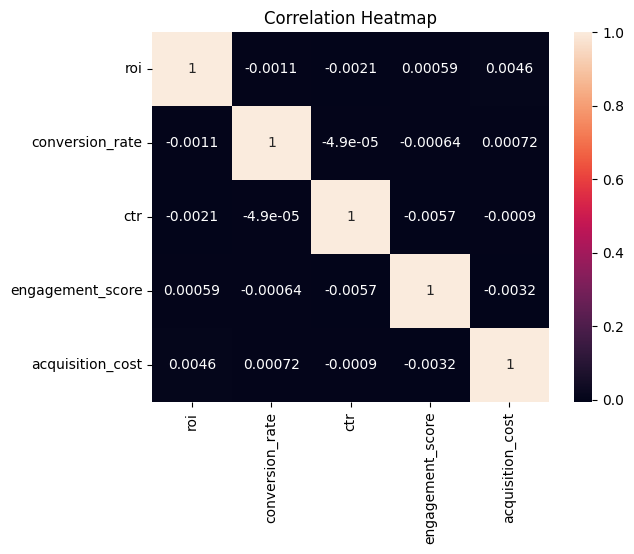

In [27]:
sns.heatmap(df[['roi','conversion_rate','ctr','engagement_score','acquisition_cost']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()